# Palace 2D Mode Analysis: Travelling-Wave Mach-Zehnder Modulator

This notebook builds a simplified cross-section of a Travelling-Wave Mach-Zehnder Modulator (TW-MZM) with a PN-junction embedded in a rib waveguide, using CPW electrodes for RF modulation.

**Cross-section geometry (from literature):**
- **SOI substrate**: 220 nm Si on 2 µm buried oxide (BOX)
- **Rib waveguide**: 400 nm width, 90 nm slab height
- **CPW electrodes**: Aluminium, 1 µm thick, signal width $w=20$ µm, gap $g=20$ µm
- **PN junction**: Centred in the rib with P+/N+ contact regions in the slab

We use `BoundaryModeSim` (Palace 2D eigenmode solver) to compute both RF and optical modes.

**Requirements:**
- gdsfactory + generic PDK (`gf.gpdk`)
- [GDSFactory+](https://gdsfactory.com) account (for cloud Palace runs)

### Build TW-MZM cross-section geometry

We define the 3D layout component that will be sliced at $x=0$ for 2D mode analysis.

**Layer assignments (gpdk):**
- `WG` (1,0): Rib waveguide core (220 nm Si, 400 nm wide)
- `SLAB90` (3,0): 90 nm slab regions
- `N` (20,0) / `P` (21,0): PN junction doping
- `NPP` (24,0) / `PP` (25,0): P+/N+ contact doping
- `M3` (49,0): CPW electrodes (Al, 1 µm thick)

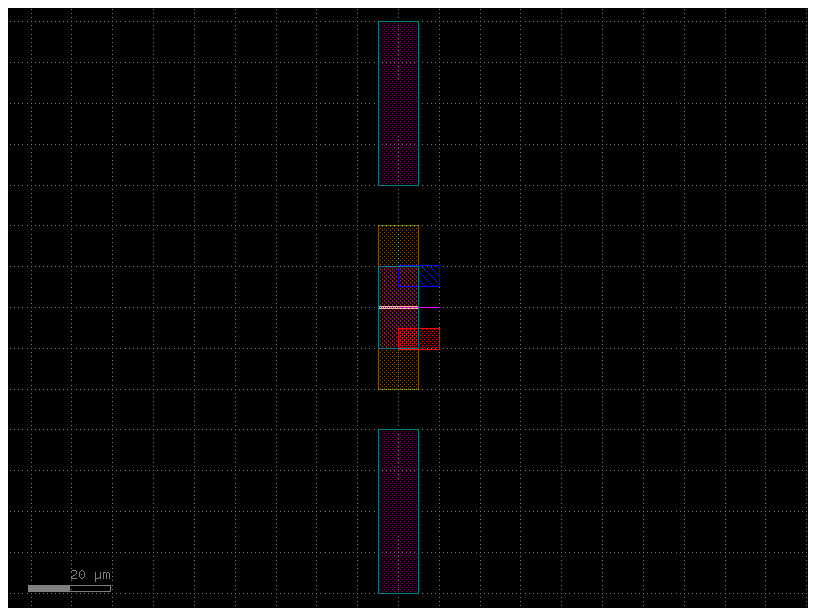

In [1]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

# ── Dimensions (um) ──────────────────────────────────────────────────────────
# Rib waveguide
RIB_WIDTH = 0.4  # 400 nm  (full ridge width)
SLAB_HALF = 20.0  # slab half-width on each side (for 40 um total)
# CPW electrodes (M3)
SIG_WIDTH = 20.0  # signal centre conductor
GAP_WIDTH = 20.0  # gap signal ↔ ground
GND_WIDTH = 40.0  # ground conductor
# Total lateral extent
TOTAL_HALF = SIG_WIDTH / 2 + GAP_WIDTH + GND_WIDTH  # 70 um
# Short x-extent for cross-section extraction
LENGTH = 10.0

# ── Helper ───────────────────────────────────────────────────────────────────
LAYER = gf.gpdk.LAYER


def centered_rect(wx: float, wy: float, layer) -> gf.Component:
    """Return a rectangle centred at the origin."""
    r = gf.Component()
    ref = r << gf.c.rectangle((wx, wy), centered=True, layer=layer)
    return r


# ═════════════════════════════════════════════════════════════════════════════
#  Component: TW-MZM cross-section
# ═════════════════════════════════════════════════════════════════════════════
comp = gf.Component()

# 1. Rib waveguide core  ───  WG layer  (full 220 nm Si)
wg = comp << centered_rect(LENGTH, RIB_WIDTH, LAYER.WG)

# 2. Slab (90 nm)  ───  SLAB90 layer  (extends on both sides)
slab = comp << centered_rect(LENGTH, 2 * SLAB_HALF + RIB_WIDTH, LAYER.SLAB90)

# 3. PN junction in the rib  ───  lateral junction
#    P side : y ∈ [0, +0.2]   (upper half of rib)
#    N side : y ∈ [-0.2, 0]   (lower half of rib)
p_half = comp << gf.c.rectangle((LENGTH, RIB_WIDTH / 2), layer=LAYER.P)
p_half.y = RIB_WIDTH / 4  # centre at +0.1 → spans [0, +0.2]

n_half = comp << gf.c.rectangle((LENGTH, RIB_WIDTH / 2), layer=LAYER.N)
n_half.y = -RIB_WIDTH / 4  # centre at -0.1 → spans [-0.2, 0]

# 4. Ohmic contact P⁺  ───  PP layer in the slab (upper side)
#    Placed far from the rib to minimise optical absorption.
PP_WIDTH = 5.0
PP_OFFSET = 5.0  # inner-edge distance from rib edge
p_plus = comp << gf.c.rectangle((LENGTH, PP_WIDTH), layer=LAYER.PP)
p_plus.y = RIB_WIDTH / 2 + PP_OFFSET + PP_WIDTH / 2  # centre → spans [+5.2, +10.2]

# 5. Ohmic contact N⁺  ───  NPP layer in the slab (lower side)
n_plus = comp << gf.c.rectangle((LENGTH, PP_WIDTH), layer=LAYER.NPP)
n_plus.y = -(RIB_WIDTH / 2 + PP_OFFSET + PP_WIDTH / 2)  # centre → spans [-10.2, -5.2]

# 6. CPW electrodes (M3)
# Signal ─ centred at y = 0
sig = comp << centered_rect(LENGTH, SIG_WIDTH, LAYER.M3)

# Ground top   ─  centred at y = SIG_WIDTH/2 + GAP_WIDTH + GND_WIDTH/2
gnd_top = comp << centered_rect(LENGTH, GND_WIDTH, LAYER.M3)
gnd_top.y = SIG_WIDTH / 2 + GAP_WIDTH + GND_WIDTH / 2

# Ground bottom
gnd_bot = comp << centered_rect(LENGTH, GND_WIDTH, LAYER.M3)
gnd_bot.y = -(SIG_WIDTH / 2 + GAP_WIDTH + GND_WIDTH / 2)

# ── Plot (full layout) ──────────────────────────────────────────────────────
_cc = comp.copy()
_cc.draw_ports()
_cc.plot()

### Inspect 2D cross-section

Before meshing, we extract the geometric cross-section at $x=0$ to verify that all layers are correctly defined.

In [ ]:
import gsim.common.cross_section as cross_section
from gsim.common.stack import get_stack
from gsim.common.stack.extractor import Layer
from gsim.common.stack.materials import (
    MaterialProperties,
    DispersionModel,
    ValidityRange,
)
from gsim.palace import BoundaryModeSim

# ── Stack ────────────────────────────────────────────────────────────────────
# We use the default gpdk stack (which already has 220 nm Si, 3 um BOX, etc.)
# then customise the metal3 thickness to 1 um to match our specification.
stack = get_stack(
    substrate_thickness=2.0,  # 2 um BOX below z=0
    include_substrate=False,  # omit lossy Si substrate
)

# Override metal3 thickness to 1 um (default is 2 um)
# Our CPW electrodes sit on the M3 layer.
m3 = stack.layers.get("metal3")
if m3:
    # Keep same zmin (3.2 um), set zmax = zmin + 1.0 um
    m3.zmax = 3.2 + 1.0
    m3.thickness = 1.0
    print(f"M3 updated: zmin={m3.zmin}, zmax={m3.zmax}, thickness={m3.thickness}")

# ── Add doping layers to the stack ───────────────────────────────────────────
# The gpdk layer_stack does not include doping (N/P/PP/NPP) as physical
# layers — they are GDS drawing layers only.  For the cross-section
# extraction to pick them up, we add them as *semiconductor* layers
# sharing the silicon z-range.
#
# IMPORTANT — material modelling note:
# We model each doping region as silicon with a *finite* conductivity derived
# from the dopant concentration via the Drude free-carrier model:
#
#     σ = q · μ · N          (q = 1.602e-19 C, μ = mobility, N = cm⁻³)
#
# Typical values (Soref & Bennett, Reed & Knights):
#   • N/P  (junction, ~1e18-1e19 cm⁻³): σ ≈ 10 - 500 S/m
#   • N+/P+ (ohmic contact, ~1e20 cm⁻³): σ ≈ 1e4 - 1e5 S/m
#
# gsim's MaterialProperties supports a Lorentzian dispersion model that
# could in principle encode the full Drude response, but the Palace
# config generator currently only consumes the scalar permittivity /
# conductivity / loss_tangent fields.  We therefore register custom
# materials with finite DC conductivity; the optical plasma-dispersion
# (Δn, Δk from free carriers) is NOT applied here — for optical mode
# analysis the rib is treated as intrinsic Si.
SI_RIB_ZMIN, SI_RIB_ZMAX = 0.0, 0.22  # full 220 nm Si
SI_SLAB_ZMAX = 0.09  # 90 nm slab

# ── Doped-silicon material definitions ───────────────────────────────────────
# Conductivities chosen from typical depletion-mode MZM doping profiles.
# NOTE: materials are registered under the *layer* names (p_rib, n_rib, ...)
# because the Palace config generator looks up materials by volume name
# (which equals the layer name) for general dielectric volumes.
doped_materials = {
    # PN junction doping (~1e19 cm⁻³, μ ≈ 100 cm²/V·s) → σ ≈ 1600 S/m
    "p_rib": MaterialProperties(
        permittivity=11.9,
        conductivity=1.6e3,
        dispersion_models=[
            DispersionModel(
                type="constant",
                permittivity=11.9,
                validity=ValidityRange(valid_frequency=(0, 200e9)),
                source="doped Si (P, ~1e19 cm⁻³) — Drude σ",
            ),
        ],
    ),
    "n_rib": MaterialProperties(
        permittivity=11.9,
        conductivity=1.6e3,
        dispersion_models=[
            DispersionModel(
                type="constant",
                permittivity=11.9,
                validity=ValidityRange(valid_frequency=(0, 200e9)),
                source="doped Si (N, ~1e19 cm⁻³) — Drude σ",
            ),
        ],
    ),
    # P+/N+ ohmic contacts (~1e20 cm⁻³, μ ≈ 50 cm²/V·s) → σ ≈ 8e4 S/m
    "pp_slab": MaterialProperties(
        permittivity=11.9,
        conductivity=8.0e4,
        dispersion_models=[
            DispersionModel(
                type="constant",
                permittivity=11.9,
                validity=ValidityRange(valid_frequency=(0, 200e9)),
                source="doped Si (P+, ~1e20 cm⁻³) — Drude σ",
            ),
        ],
    ),
    "npp_slab": MaterialProperties(
        permittivity=11.9,
        conductivity=8.0e4,
        dispersion_models=[
            DispersionModel(
                type="constant",
                permittivity=11.9,
                validity=ValidityRange(valid_frequency=(0, 200e9)),
                source="doped Si (N+, ~1e20 cm⁻³) — Drude σ",
            ),
        ],
    ),
}

# Register the custom materials in the stack's materials dict so the
# Palace config generator picks them up.  Keys must match the layer
# names (volume names) for the general-volume material lookup path.
for name, props in doped_materials.items():
    stack.materials[name] = props.to_dict()

# ── Doping layer definitions (semiconductor, finite σ) ──────────────────────
# layer_type="dielectric" so the mesh generator creates volumetric
# domains (not PEC surfaces) with finite conductivity from the material.
doping_layers = {
    "p_rib": Layer(
        name="p_rib",
        gds_layer=LAYER.P,
        zmin=SI_RIB_ZMIN,
        zmax=SI_RIB_ZMAX,
        thickness=SI_RIB_ZMAX - SI_RIB_ZMIN,
        material="p_rib",
        layer_type="dielectric",
        mesh_resolution="fine",
    ),
    "n_rib": Layer(
        name="n_rib",
        gds_layer=LAYER.N,
        zmin=SI_RIB_ZMIN,
        zmax=SI_RIB_ZMAX,
        thickness=SI_RIB_ZMAX - SI_RIB_ZMIN,
        material="n_rib",
        layer_type="dielectric",
        mesh_resolution="fine",
    ),
    "pp_slab": Layer(
        name="pp_slab",
        gds_layer=LAYER.PP,
        zmin=SI_RIB_ZMIN,
        zmax=SI_SLAB_ZMAX,
        thickness=SI_SLAB_ZMAX - SI_RIB_ZMIN,
        material="pp_slab",
        layer_type="dielectric",
        mesh_resolution="fine",
    ),
    "npp_slab": Layer(
        name="npp_slab",
        gds_layer=LAYER.NPP,
        zmin=SI_RIB_ZMIN,
        zmax=SI_SLAB_ZMAX,
        thickness=SI_SLAB_ZMAX - SI_RIB_ZMIN,
        material="npp_slab",
        layer_type="dielectric",
        mesh_resolution="fine",
    ),
}
for name, layer in doping_layers.items():
    stack.layers[name] = layer

print(f"Stack: {stack.pdk_name}")
print("Layers:", sorted(stack.layers.keys()))
print("Custom materials:", sorted(doped_materials.keys()))
print("Dielectrics:", stack.dielectrics)
print()

# ── Cross-section extraction ────────────────────────────────────────────────
section = cross_section.extract_plane_section(comp.copy(), stack, axis="x", value=0.0)
print(f"Cross-section x=0 intersects {len(section)} layer regions:")
for r in section:
    print(
        f"  {r.layer_name:12s}  material={r.material:10s}  "
        f"y=[{r.y0:8.3f}, {r.y1:8.3f}]  z=[{r.zmin:6.3f}, {r.zmax:6.3f}]"
    )

M3 updated: zmin=3.2, zmax=4.2, thickness=1.0
Stack: generic
Layers: ['box', 'clad', 'core', 'deep_etch', 'ge', 'heater', 'metal1', 'metal2', 'metal3', 'n_rib', 'nitride', 'npp_slab', 'p_rib', 'pp_slab', 'shallow_etch', 'slab150', 'slab90', 'undercut', 'via1', 'via2', 'via_contact']
Custom materials: ['n_rib', 'npp_slab', 'p_rib', 'pp_slab']
Dielectrics: [{'name': 'oxide', 'zmin': -2.0, 'zmax': 5.2, 'material': 'sio2'}, {'name': 'passive', 'zmin': 5.2, 'zmax': 5.6000000000000005, 'material': 'passive'}]

Cross-section x=0 intersects 9 layer regions:
  core          material=si          y=[  -0.200,    0.200]  z=[ 0.000,  0.220]
  slab90        material=si          y=[ -20.200,   20.200]  z=[ 0.000,  0.090]
  metal3        material=Aluminum    y=[ -70.000,  -30.000]  z=[ 3.200,  4.200]
  metal3        material=Aluminum    y=[ -10.000,   10.000]  z=[ 3.200,  4.200]
  metal3        material=Aluminum    y=[  30.000,   70.000]  z=[ 3.200,  4.200]
  p_rib         material=p_rib       y=[   0

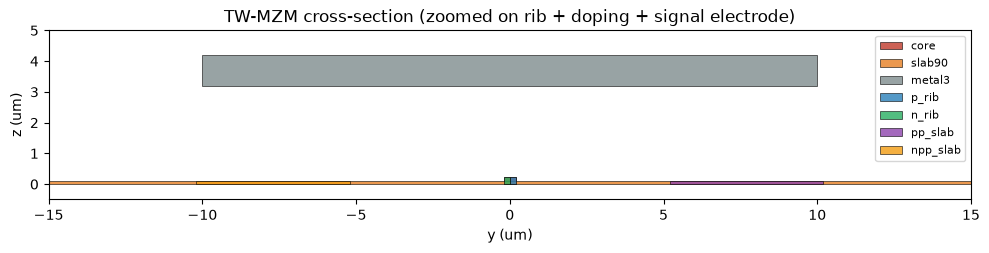

In [ ]:
# ── Zoomed cross-section plot (rib region) ──────────────────────────────────
# The full layout spans 140 um, so the 400 nm rib is invisible at full scale.
# Here we plot only the central ±15 um to show the rib, PN junction, and
# the P⁺/N⁺ ohmic contacts clearly.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 4))

# Colour map per layer name
colors = {
    "core": "#c0392b",  # rib Si — red
    "slab90": "#e67e22",  # slab Si — orange
    "p_rib": "#2980b9",  # P doping — blue
    "pp_slab": "#8e44ad",  # P⁺ contact — purple (distinct hue from blue)
    "n_rib": "#27ae60",  # N doping — green
    "npp_slab": "#4460ad",  # N⁺ contact — amber/gold (distinct contrast from green)
    "metal3": "#7f8c8d",  # Al — grey
}

for r in section:
    c = colors.get(r.layer_name, "#dddddd")
    # RectYZ2D: y0/y1 are lateral, zmin/zmax are vertical
    rect = Rectangle(
        (r.y0, r.zmin),
        r.y1 - r.y0,
        r.zmax - r.zmin,
        facecolor=c,
        edgecolor="k",
        linewidth=0.5,
        alpha=0.8,
        label=r.layer_name,
    )
    ax.add_patch(rect)

ax.set_xlim(-15, 15)
ax.set_ylim(-0.5, 5.0)
ax.set_aspect("equal")
ax.set_xlabel("y (um)")
ax.set_ylabel("z (um)")
ax.set_title("TW-MZM cross-section (zoomed on rib + doping + signal electrode)")

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
# ── BoundaryMode 2D simulation setup ────────────────────────────────────────
sim = BoundaryModeSim()
sim.set_output_dir("./palace-sim-mzm-pn")

# Custom stack with modified M3 + doping layers
sim.set_stack(stack)
sim.set_airbox(margin_x=50.0, margin_y=50.0, z_above=100.0, z_below=100.0)
sim.set_geometry(comp)

sim.set_cross_section("x=0")
sim.set_boundary_mode(freq=50e9, num_modes=2, save=2)

# ── Mesh ─────────────────────────────────────────────────────────────────────
# refined_mesh_size must be smaller than the rib (0.4 um wide, 0.22 um tall)
# to resolve the waveguide geometry.  Use 0.05 um near conductors.
sim.mesh(
    preset="default",
    refined_mesh_size=0.05,  # resolve the 400 nm rib
    max_mesh_size=40.0,
    fmax=150e9,
    margin_x=0.0,
    margin_y=50.0,
)

# Show the 2D domain groups created by the solver
domain_groups = list(sim._last_mesh_result.groups["volumes"].keys())
print("2D domain groups:", domain_groups)

2D domain groups: ['core', 'n_rib', 'npp_slab', 'p_rib', 'passive', 'pp_slab', 'sio2', 'slab90', 'air']


In [5]:
# Interactive 3D mesh visualisation
# (Groups depend on what the mesh generator creates — port surfaces
#  like P1_E0 are absent in BoundaryMode 2D native mode)
sim.plot_mesh(
    transparent_groups=["air__None", "air__passive", "oxide__passive"],
    style="solid",
    interactive=True,
)

Widget(value='<iframe src="http://localhost:34001/index.html?ui=P_0x7d90e1da7470_0&reconnect=auto" class="pyvi…

In [6]:
# Generate Palace config file (mesh must be present)
sim.write_config()
print("Config written to:", sim.output_dir)

Config written to: palace-sim-mzm-pn


### RF mode analysis (50 GHz)

The BoundaryMode solver computes propagation constants and mode profiles at the RF frequency.  
We demonstrate the setup below — uncomment the `run_local` call when ready to execute.

In [7]:
# Run on cloud (GDSFactory+) or local Palace installation

# results = sim.run()
# results.print()

# Or run locally:
# palace_executable = "/path/to/palace/build/bin/palace"
# results = sim.run_local(palace_executable=palace_executable, num_processes=16)

### Optical mode analysis (1550 nm)

The same cross-section can be analysed at optical frequencies ($\lambda = 1.55$ µm) to compute the optical mode confined in the rib waveguide.  Here we set up a second `BoundaryModeSim` targeting the optical regime.

In [8]:
# Optical mode at 1550 nm (~193.4 THz)
f_opt = 193.4e12  # Hz

sim_opt = BoundaryModeSim()
sim_opt.set_output_dir("./palace-sim-mzm-pn-opt")
sim_opt.set_stack(stack)
sim_opt.set_airbox(margin_x=50.0, margin_y=50.0, z_above=100.0, z_below=100.0)
sim_opt.set_geometry(comp)

sim_opt.set_cross_section("x=0")
sim_opt.set_boundary_mode(
    freq=f_opt,
    num_modes=4,  # fundamental TE/TM + higher-order
    save=2,
    target=2.5,  # n_eff guess for Si rib waveguide
    tolerance=1e-8,
)

sim_opt.mesh(
    preset="default",
    refined_mesh_size=0.02,  # very fine — optical mode in 400 nm rib
    max_mesh_size=0.5,
    margin_x=0.0,
    margin_y=50.0,
)

domain_groups_opt = list(sim_opt._last_mesh_result.groups["volumes"].keys())
print("Optical 2D domain groups:", domain_groups_opt)
print("Config ready at:", sim_opt.output_dir)
sim_opt.write_config()

Optical 2D domain groups: ['core', 'n_rib', 'npp_slab', 'p_rib', 'passive', 'pp_slab', 'sio2', 'slab90', 'air']
Config ready at: palace-sim-mzm-pn-opt


PosixPath('palace-sim-mzm-pn-opt/config.json')

### Summary

The geometry has been built and meshed for both RF (50 GHz) and optical (193 THz / 1550 nm) analysis.

**Cross-section elements:**
| Component | Layer | y-range (µm) | z-range (µm) | Material | σ (S/m) |
|---|---|---|---|---|---|
| Rib core | WG (1,0) | [-0.2, +0.2] | [0, 0.22] | Si (intrinsic) | 2 |
| Slab (90 nm) | SLAB90 (3,0) | [-20.2, +20.2] | [0, 0.09] | Si (intrinsic) | 2 |
| PN junction (P) | P (21,0) | [0, +0.2] | [0, 0.22] | doped Si | 1.6×10³ |
| PN junction (N) | N (20,0) | [-0.2, 0] | [0, 0.22] | doped Si | 1.6×10³ |
| P⁺ contact | PP (23,0) | [+5.2, +10.2] | [0, 0.09] | doped Si | 8×10⁴ |
| N⁺ contact | NPP (24,0) | [-10.2, -5.2] | [0, 0.09] | doped Si | 8×10⁴ |
| CPW signal | M3 (49,0) | [-10, +10] | [3.2, 4.2] | Al (1 µm) | 3.5×10⁷ |
| CPW ground (top) | M3 (49,0) | [+30, +70] | [3.2, 4.2] | Al (1 µm) | 3.5×10⁷ |
| CPW ground (bot) | M3 (49,0) | [-70, -30] | [3.2, 4.2] | Al (1 µm) | 3.5×10⁷ |

**Material modelling notes:**
- Doping regions are modelled as **semiconductors** (finite σ from Drude free-carrier model), not metals. This avoids short-circuiting the PN junction.
- Conductivities are derived from $\sigma = q\mu N$ with typical dopant concentrations ($N \sim 10^{19}$ cm⁻³ for the junction, $\sim 10^{20}$ cm⁻³ for the contacts).
- The **depletion region** and voltage-dependent capacitance are NOT modelled here — this is a linear small-signal analysis at a fixed bias point.
- The **plasma-dispersion effect** (free-carrier $\Delta n$, $\Delta k$) is not applied to the optical simulation; the rib is treated as intrinsic Si at 1550 nm. A full electro-optic analysis would require a separate carrier-dependent optical material model (Soref–Bennett).

**Next steps (user action):**
1. Verify the zoomed cross-section plot above shows the rib, PN junction, and contacts.
2. Configure a Palace executable path and run `sim.run_local(...)` for RF modes.
3. Run `sim_opt.run_local(...)` for optical modes.
4. Use `gsim.palace.plot_fields_2d()` to visualise mode profiles.

In [9]:
# Quick verification: dump the 2D cross-section layer regions
print("=== RF cross-section regions (x=0) ===")
for r in section:
    print(
        f"  {r.layer_name:12s}  mat={r.material:10s}  "
        f"y=[{r.y0:6.2f},{r.y1:6.2f}]  z=[{r.zmin:5.3f},{r.zmax:5.3f}]"
    )

=== RF cross-section regions (x=0) ===
  core          mat=si          y=[ -0.20,  0.20]  z=[0.000,0.220]
  slab90        mat=si          y=[-20.20, 20.20]  z=[0.000,0.090]
  metal3        mat=Aluminum    y=[-70.00,-30.00]  z=[3.200,4.200]
  metal3        mat=Aluminum    y=[-10.00, 10.00]  z=[3.200,4.200]
  metal3        mat=Aluminum    y=[ 30.00, 70.00]  z=[3.200,4.200]
  p_rib         mat=p_rib       y=[  0.00,  0.20]  z=[0.000,0.220]
  n_rib         mat=n_rib       y=[ -0.20,  0.00]  z=[0.000,0.220]
  pp_slab       mat=pp_slab     y=[  5.20, 10.20]  z=[0.000,0.090]
  npp_slab      mat=npp_slab    y=[-10.20, -5.20]  z=[0.000,0.090]
